# QeMFi Surrogate Test & Evaluation

Load a trained surrogate, evaluate on the test split, and generate plots.


In [9]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))




import joblib
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader

import aimvee
from aimvee import models
from aimvee.qemfi_utils.load_dataset import QemfiDataset as Dataset
from aimvee.qemfi_utils.train_utils import eval_epoch
from aimvee.utils import select_device

Model = models.QemfiSurrogate



In [10]:
data_dir = repo_root / "data" / "QeMFI_all" / "model_training_test_data"
model_dir = repo_root / "models" / "qemfi_surrogate"

model_path = model_dir / "best_model.pt"
scaler_path = model_dir / "scaler_X.pkl"
scaler_y_path = model_dir / "scaler_y.pkl"
pca_path = model_dir / "pca_X.pkl"

cm_to_ev = 1.239841984e-4  # Convert cm^-1 to eV


In [11]:
# Load test arrays
x_test = np.load(data_dir / "CM_test.npy")
y_test = np.load(data_dir / "EV_test.npy")
print("Test shapes:", x_test.shape, y_test.shape)

mask_test = y_test >= 0
print(f"Dropping {np.sum(~mask_test)} invalid test rows (y < 0)")
x_test = x_test[mask_test]
y_test = y_test[mask_test]

d_rep_raw = x_test.shape[1] - 2
x_test_rep = x_test[:, :d_rep_raw].astype(np.float32)
x_test_idx = x_test[:, d_rep_raw:].astype(np.int64)

scaler_x: StandardScaler = joblib.load(scaler_path)
scaler_y: StandardScaler = joblib.load(scaler_y_path)
pca: PCA = joblib.load(pca_path)

x_test_rep = scaler_x.transform(x_test_rep)
x_test_rep = pca.transform(x_test_rep)

y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

d_rep_pca = x_test_rep.shape[1]
print("Test representation dim after PCA:", d_rep_pca)

expected = getattr(pca, "n_components_", None)
if expected is not None:
    assert d_rep_pca == expected, (
        f"PCA dim mismatch: got {d_rep_pca}, expected {expected}"
    )

x_test = np.concatenate([x_test_rep.astype(np.float32), x_test_idx.astype(np.int64)], axis=1)

test_ds = Dataset(x_test, y_test_scaled)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

d_rep = d_rep_pca
n_fids = test_ds.n_fids
n_states = test_ds.n_states
print(f"[TEST] d_rep={d_rep}, n_fids={n_fids}, n_states={n_states}")

device = select_device("")
print("Using device:", device)

model = Model(
    d_rep=d_rep,
    n_fids=n_fids,
    n_states=n_states,
    hidden_dim=512,
    emb_dim=32,
    dropout=0.05,
).to(device)

if not model_path.exists():
    raise FileNotFoundError(f"Could not find model checkpoint at {model_path}")

state = torch.load(model_path, map_location=device)
model.load_state_dict(state, strict=True)
print(f"Loaded model weights from: {model_path}")

test_mae_cm = eval_epoch(
    model,
    test_loader,
    device=device,
    target_scale=float(scaler_y.scale_[0]),
)
test_mae_ev = test_mae_cm * cm_to_ev

print(f"FINAL TEST RESULTS (QeMFi surrogate): Test MAE: {test_mae_cm:.2f} cm^-1 ({test_mae_ev:.6f} eV)")

Test shapes: (130000, 255) (130000,)
Dropping 0 invalid test rows (y < 0)
Test representation dim after PCA: 100
[TEST] d_rep=100, n_fids=5, n_states=10
Using device: cpu
Loaded model weights from: /Users/lohitakshbadarala/Desktop/AIM-VEE/models/qemfi_surrogate/best_model.pt


/opt/anaconda3/envs/aim_vee/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/aim_vee/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/var/folders/qx/550h11x507v2gx31q3c186qm0000gn/T/ipykernel_24409/24794568.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses th

FINAL TEST RESULTS (QeMFi surrogate): Test MAE: 958.07 cm^-1 (0.118786 eV)


In [12]:
def collect_predictions(model, loader, device):
    model.eval()
    ys, preds, fids, states = [], [], [], []

    with torch.no_grad():
        for batch in loader:
            feats = batch["feats"].to(device).float()
            fid_id = batch["fid_id"].to(device).long()
            state = batch["state_id"].to(device).long()
            target = batch["target"].to(device).float()

            y_hat = model(feats, fid_id, state)

            ys.append(target.cpu().numpy())
            preds.append(y_hat.cpu().numpy())
            fids.append(fid_id.cpu().numpy())
            states.append(state.cpu().numpy())

    return (
        np.concatenate(ys),
        np.concatenate(preds),
        np.concatenate(fids),
        np.concatenate(states),
    )


y_true_scaled, y_pred_scaled, fid_ids, state_ids = collect_predictions(
    model, test_loader, device
)

scale = float(scaler_y.scale_[0])
mean = float(scaler_y.mean_[0])

y_true_cm = y_true_scaled * scale + mean
y_pred_cm = y_pred_scaled * scale + mean

y_true_ev = y_true_cm * cm_to_ev
y_pred_ev = y_pred_cm * cm_to_ev
errors_ev = np.abs(y_pred_ev - y_true_ev)


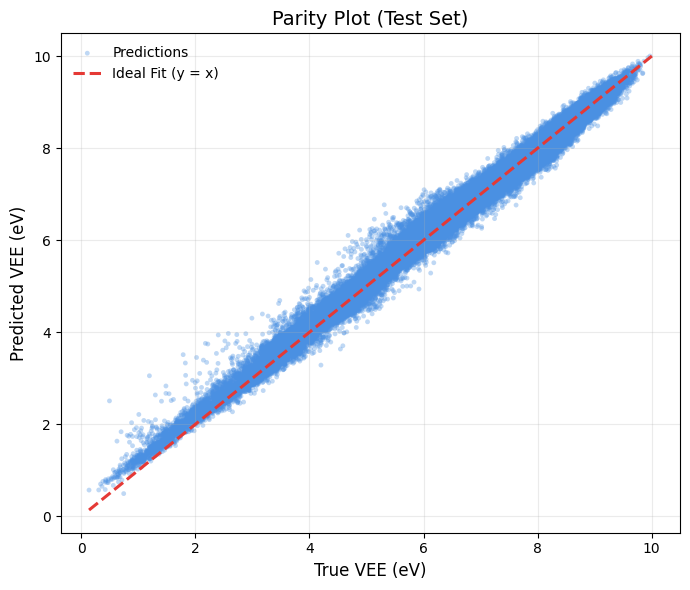

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,6))

# Scatter points
plt.scatter(
    y_true_ev,
    y_pred_ev,
    s=12,
    alpha=0.35,
    color="#4A90E2",
    edgecolors="none",
    label="Predictions"
)

# Identity  line
min_val = min(y_true_ev.min(), y_pred_ev.min())
max_val = max(y_true_ev.max(), y_pred_ev.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="#E53935",
    linestyle="--",
    linewidth=2.2,
    label="Ideal Fit (y = x)"
)

# Labels
plt.xlabel("True VEE (eV)", fontsize=12)
plt.ylabel("Predicted VEE (eV)", fontsize=12)
plt.title("Parity Plot (Test Set)", fontsize=14)

# Styling
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()

plt.show()


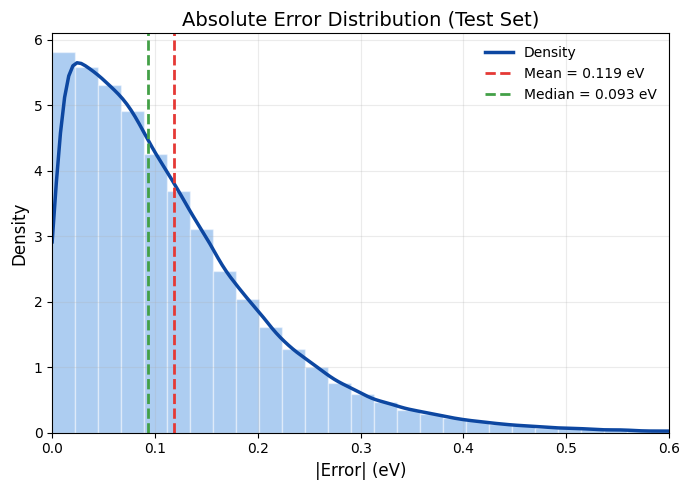

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Compute KDE
kde = gaussian_kde(errors_ev)
x_vals = np.linspace(min(errors_ev), max(errors_ev), 500)

# Compute stats
mean_err = np.mean(errors_ev)
median_err = np.median(errors_ev)

# Plot
plt.figure(figsize=(7,5))

# Histogram
plt.hist(errors_ev, bins=90, density=True, alpha=0.45, color="#4A90E2", edgecolor="white")

# Smoothed KDE line
plt.plot(x_vals, kde(x_vals), color="#0D47A1", linewidth=2.5, label="Density")

# Mean + median vertical lines
plt.axvline(mean_err, color="#E53935", linestyle="--", linewidth=2, label=f"Mean = {mean_err:.3f} eV")
plt.axvline(median_err, color="#43A047", linestyle="--", linewidth=2, label=f"Median = {median_err:.3f} eV")

# Labels & title
plt.xlabel("|Error| (eV)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Absolute Error Distribution (Test Set)", fontsize=14)
plt.xlim(0, 0.6)

# Styling
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()

plt.show()


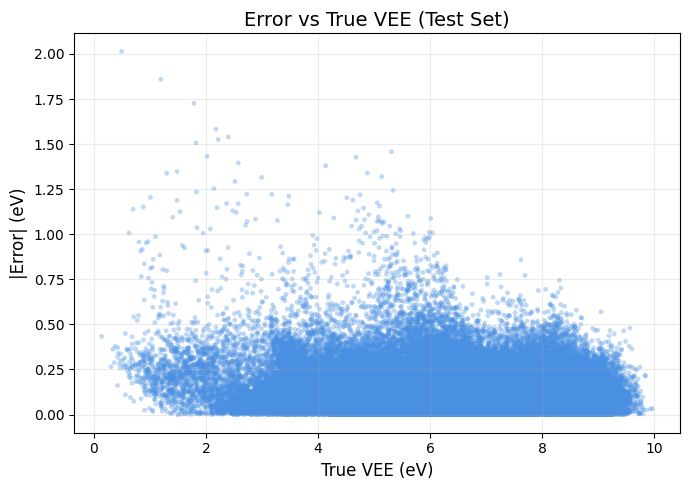

In [15]:


plt.figure(figsize=(7,5))

# Scatter points
plt.scatter(
    y_true_ev,
    errors_ev,
    s=12,
    alpha=0.35,
    color="#4A90E2",
    edgecolors="none",
    label="Error Points"
)

# Labels
plt.xlabel("True VEE (eV)", fontsize=12)
plt.ylabel("|Error| (eV)", fontsize=12)
plt.title("Error vs True VEE (Test Set)", fontsize=14)

# Styling
plt.grid(True, alpha=0.25)
plt.tight_layout()

plt.show()



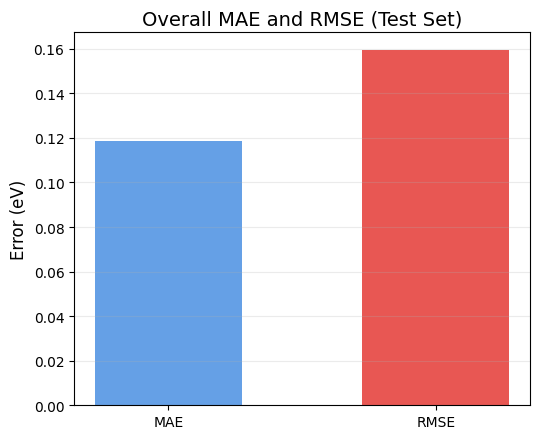

In [16]:
# Overall MAE and RMSE (total test set)

err = y_pred_ev - y_true_ev
mae_total = np.mean(np.abs(err))
rmse_total = np.sqrt(np.mean(err ** 2))

labels = ["MAE", "RMSE"]
values = [mae_total, rmse_total]
colors = ["#4A90E2", "#E53935"]

plt.figure(figsize=(5.5, 4.5))
plt.bar(labels, values, color=colors, alpha=0.85, width=0.55)

plt.ylabel("Error (eV)", fontsize=12)
plt.title("Overall MAE and RMSE (Test Set)", fontsize=14)
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
